In [360]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns   
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score ,mean_squared_error, mean_absolute_error
import pickle

In [279]:
df = pd.read_csv('laptopData.csv')
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298.0,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299.0,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300.0,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301.0,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [280]:
df.shape

(1303, 12)

In [281]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [282]:
df.describe(include='all')

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
count,1273.000000,1273,1273,1273,1273,1273,1273,1273,1273,1273,1273,1273.000000
unique,NaN,19,6,25,40,118,10,40,110,9,189,NaN
top,NaN,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,NaN,290,710,640,495,183,601,401,271,1047,111,NaN
mean,652.674784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59955.814073
std,376.493027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37332.251005
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9270.720000
25%,327.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31914.720000
50%,652.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52161.120000
75%,980.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79333.387200


In [283]:
df.isnull().sum() 

Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [284]:
df.duplicated().sum()

np.int64(29)

In [285]:
df[df.duplicated(keep=False)]

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [286]:
df.drop_duplicates(inplace=True)
df.isna().sum()


Unnamed: 0          1
Company             1
TypeName            1
Inches              1
ScreenResolution    1
Cpu                 1
Ram                 1
Memory              1
Gpu                 1
OpSys               1
Weight              1
Price               1
dtype: int64

In [287]:
df[df.isna().any(axis=1)]

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [288]:
df.dropna(how='all', inplace=True)

In [289]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [290]:
df.drop(columns=['Unnamed: 0'], inplace=True)


In [291]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [292]:
for i in df.columns:
    if i != 'Price':
        print(f"Value counts for {i}:")
        print(df[i].value_counts())
        print("-----------------------------")

Value counts for Company:
Company
Lenovo       290
Dell         287
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
LG             3
Google         3
Huawei         2
Fujitsu        2
Name: count, dtype: int64
-----------------------------
Value counts for TypeName:
TypeName
Notebook              710
Gaming                203
Ultrabook             191
2 in 1 Convertible    116
Workstation            29
Netbook                24
Name: count, dtype: int64
-----------------------------
Value counts for Inches:
Inches
15.6    640
14      192
17.3    162
13.3    161
12.5     38
11.6     31
12        6
13.9      6
13.5      5
12.3      5
15.4      4
15        4
10.1      3
35.6      3
13        2
24        2
18.4      1
27.3      1
25.6      1
33.5      1
?         1
17        1
31.6      1
14.1      1
11.3      1
Name: c

In [293]:
df['Ram'] = df['Ram'].astype(str).str.replace('GB', '').astype(int)
df['Weight'] = pd.to_numeric(
    df['Weight']
    .astype(str)
    .str.replace('kg', '', regex=False)
    .str.replace('?', '', regex=False)
    .str.strip(),
    errors='coerce'
).astype(float)

In [294]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [295]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              1
Price               0
dtype: int64

In [296]:
df[df['Weight'].isnull()]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
208,Dell,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,NaN,77202.72


In [297]:
df['Weight'] = df.groupby('TypeName')['Weight'].transform(
    lambda x: x.fillna(x.mean())
)
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [298]:
df['Inches'] = df['Inches'].astype(str).str.replace('?', 'NaN').astype(float)

In [299]:
df[df['Inches'].isnull()]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
476,Dell,Workstation,NaN,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78,128298.24


In [300]:
df['Inches'] = df.groupby('TypeName')['Inches'].transform(
    lambda x: x.fillna(x.mean())
)

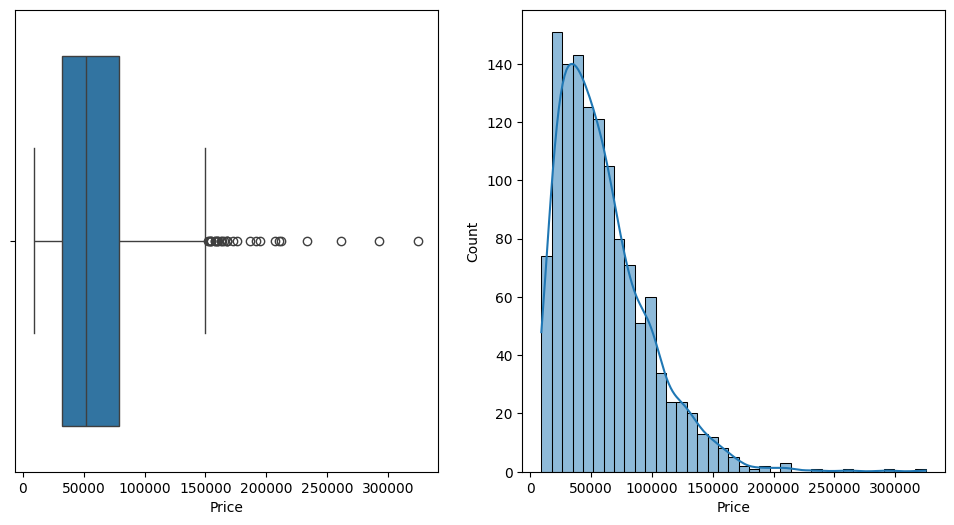

In [301]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.boxplot(x=df['Price'])

plt.subplot(1,2,2)
sns.histplot(df['Price'], kde=True)

plt.show()


In [302]:
df['log_Price'] = np.log(df['Price'])

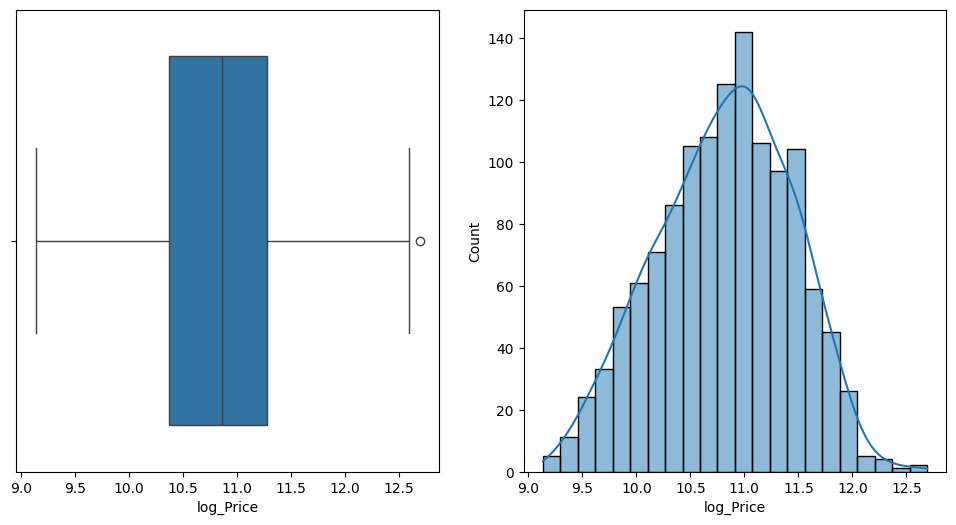

In [303]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.boxplot(x=df['log_Price'])

plt.subplot(1,2,2)
sns.histplot(df['log_Price'], kde=True)

plt.show()


In [304]:
q1 = df['Price'].quantile(0.25)
q3 =df['Price'].quantile(0.75)
iqr = q3 - q1   
upper_bound = q3 + 1.5 * iqr
outliers = df[df['Price'] > upper_bound]
outliers

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,log_Price
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512GB SSD,AMD Radeon Pro 560,macOS,1.83,152274.2400,11.933438
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,324954.7200,12.691441
204,Dell,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16,256GB SSD + 1TB HDD,Nvidia Quadro M1200,Windows 10,2.80,162770.4000,12.000096
238,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,32,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1080,Windows 10,4.70,207259.2000,12.241725
247,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,16,256GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.60,159786.7200,11.981595
297,Dell,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16,256GB SSD,Nvidia Quadro M1200,Windows 10,3.42,153705.3408,11.942793
517,Asus,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,24,512GB SSD,Nvidia GeForce GTX1080,Windows 10,2.24,158135.0400,11.971205
530,Dell,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42,160520.3856,11.986176
563,Lenovo,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,256GB SSD,Nvidia Quadro M620M,Windows 10,3.40,159786.7200,11.981595
610,Lenovo,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.50,261018.7200,12.472347


In [305]:
df["Touchscreen"] = df["ScreenResolution"].apply(
    lambda x: 1 if "Touchscreen" in x else 0
)

In [306]:
df['IPS']=df['ScreenResolution'].apply(lambda x : 1 if 'IPS' in x else 0)

In [307]:
df["X_res"] = df["ScreenResolution"].str.extract(r'(\d+)x(\d+)')[0].astype(float)
df["Y_res"] = df["ScreenResolution"].str.extract(r'(\d+)x(\d+)')[1].astype(float)

In [314]:
df["PPI"] = np.sqrt(df["X_res"]**2 + df["Y_res"]**2) / df["Inches"]

In [315]:
df["Cpu_brand"]=df['Cpu'].apply(lambda x : x.split()[0])
df["Gpu_brand"]=df['Gpu'].apply(lambda x : x.split()[0])


In [316]:
df['Cpu_freq'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz').astype(float)

In [317]:
df['Memory'] = df['Memory'].str.replace('TB','000GB')

In [318]:
df[df['Memory']=='?']

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,log_Price,Touchscreen,IPS,X_res,Y_res,PPI,Cpu_brand,Gpu_brand,Cpu_freq
770,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,?,AMD Radeon R7 M445,Windows 10,2.3,62938.0656,11.049906,0,0,1920.0,1080.0,141.211998,Intel,AMD,2.7


In [321]:
df['Memory'].replace('?',np.nan,inplace=True)
df['Memory'].fillna(df['Memory'].mode()[0], inplace=True)

In [322]:
df['Memory'] = df['Memory'].astype(str)

df['SSD'] = df['Memory'].str.extract(r'(\d+)GB SSD')[0]
df['HDD'] = df['Memory'].str.extract(r'(\d+)GB HDD')[0]
df['Flash_Storage'] = df['Memory'].str.extract(r'(\d+)GB Flash Storage')[0]
df['Hybrid'] = df['Memory'].str.extract(r'(\d+)GB Hybrid')[0]

df[['SSD','HDD','Flash_Storage','Hybrid']] = df[['SSD','HDD','Flash_Storage','Hybrid']].fillna(0).astype(int)

In [323]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,X_res,Y_res,PPI,Cpu_brand,Gpu_brand,Cpu_freq,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,2560.0,1600.0,226.983005,Intel,Intel,2.3,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,1440.0,900.0,127.677940,Intel,Intel,1.8,0,0,128,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,...,1920.0,1080.0,141.211998,Intel,Intel,2.5,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,...,2880.0,1800.0,220.534624,Intel,AMD,2.7,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,...,2560.0,1600.0,226.983005,Intel,Intel,3.1,256,0,0,0


In [324]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1273 entries, 0 to 1302
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1273 non-null   object 
 1   TypeName          1273 non-null   object 
 2   Inches            1273 non-null   float64
 3   ScreenResolution  1273 non-null   object 
 4   Cpu               1273 non-null   object 
 5   Ram               1273 non-null   int64  
 6   Memory            1273 non-null   object 
 7   Gpu               1273 non-null   object 
 8   OpSys             1273 non-null   object 
 9   Weight            1273 non-null   float64
 10  Price             1273 non-null   float64
 11  log_Price         1273 non-null   float64
 12  Touchscreen       1273 non-null   int64  
 13  IPS               1273 non-null   int64  
 14  X_res             1273 non-null   float64
 15  Y_res             1273 non-null   float64
 16  PPI               1273 non-null   float64
 17  

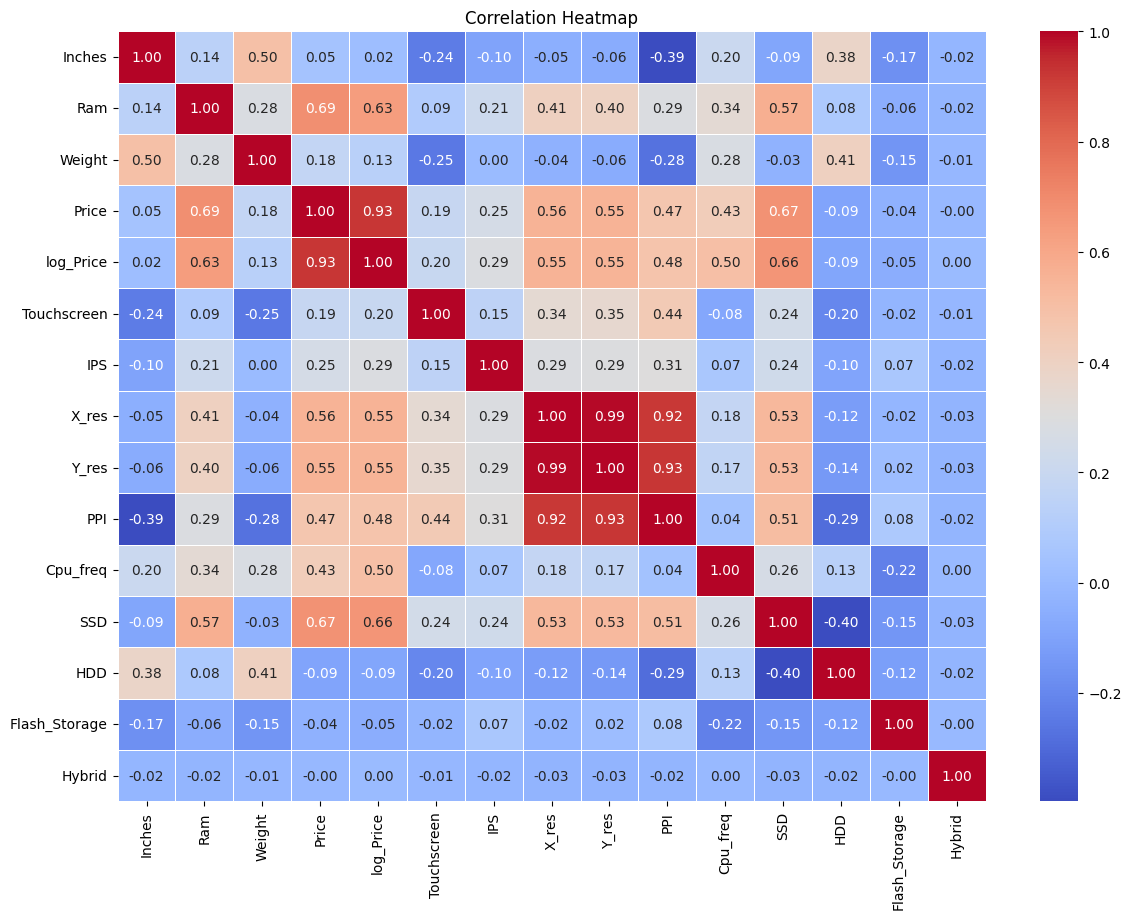

In [325]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'


)
plt.title('Correlation Heatmap')
plt.show()


In [326]:
df.drop(columns=['ScreenResolution','Cpu','Gpu','Memory'], inplace=True)

In [327]:
df.head()

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,log_Price,Touchscreen,IPS,X_res,Y_res,PPI,Cpu_brand,Gpu_brand,Cpu_freq,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,8,macOS,1.37,71378.6832,11.175755,0,1,2560.0,1600.0,226.983005,Intel,Intel,2.3,128,0,0,0
1,Apple,Ultrabook,13.3,8,macOS,1.34,47895.5232,10.776777,0,0,1440.0,900.0,127.677940,Intel,Intel,1.8,0,0,128,0
2,HP,Notebook,15.6,8,No OS,1.86,30636.0000,10.329931,0,0,1920.0,1080.0,141.211998,Intel,Intel,2.5,256,0,0,0
3,Apple,Ultrabook,15.4,16,macOS,1.83,135195.3360,11.814476,0,1,2880.0,1800.0,220.534624,Intel,AMD,2.7,512,0,0,0
4,Apple,Ultrabook,13.3,8,macOS,1.37,96095.8080,11.473101,0,1,2560.0,1600.0,226.983005,Intel,Intel,3.1,256,0,0,0


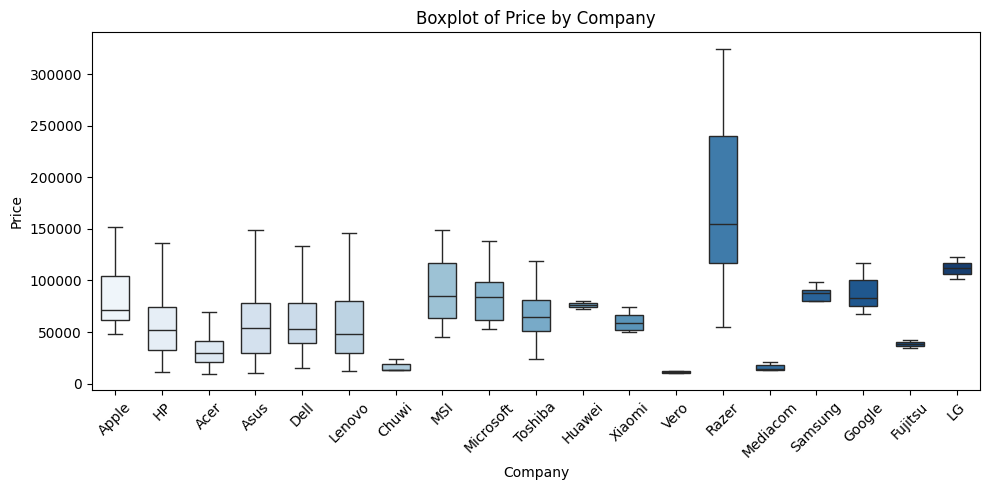

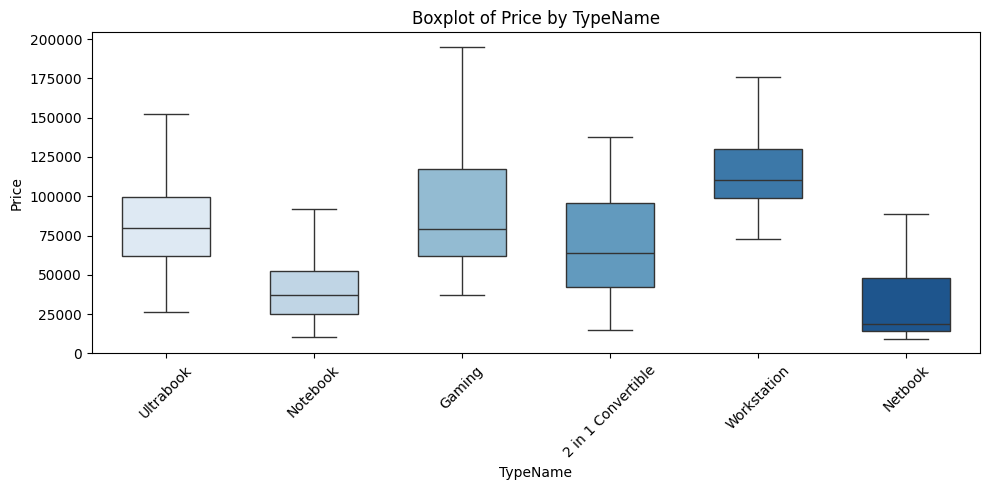

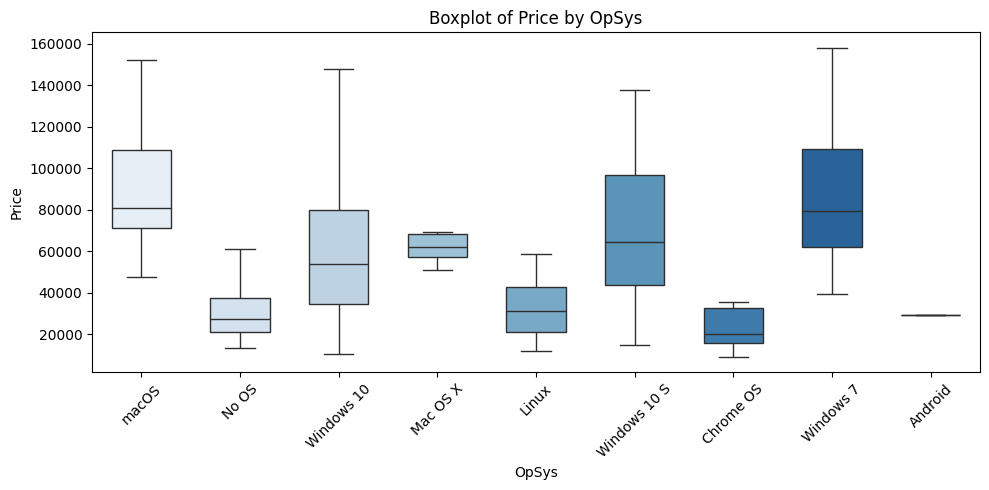

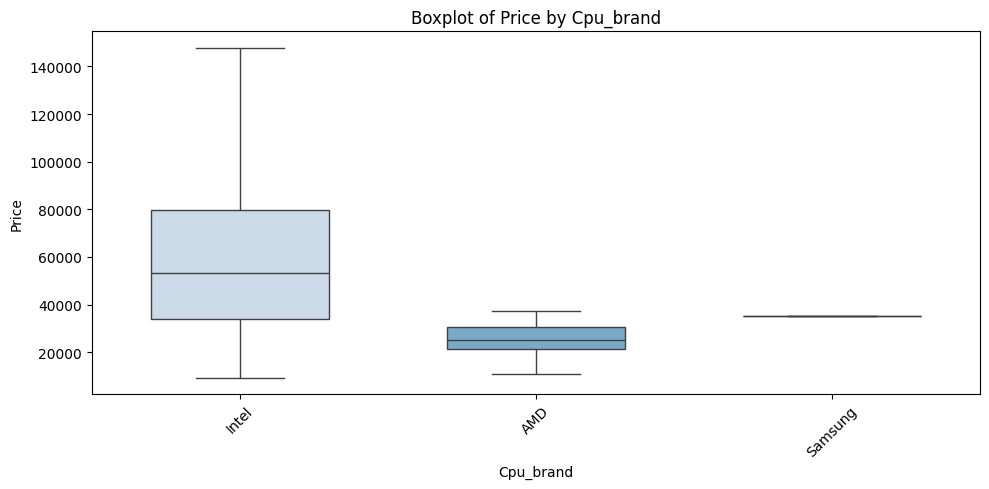

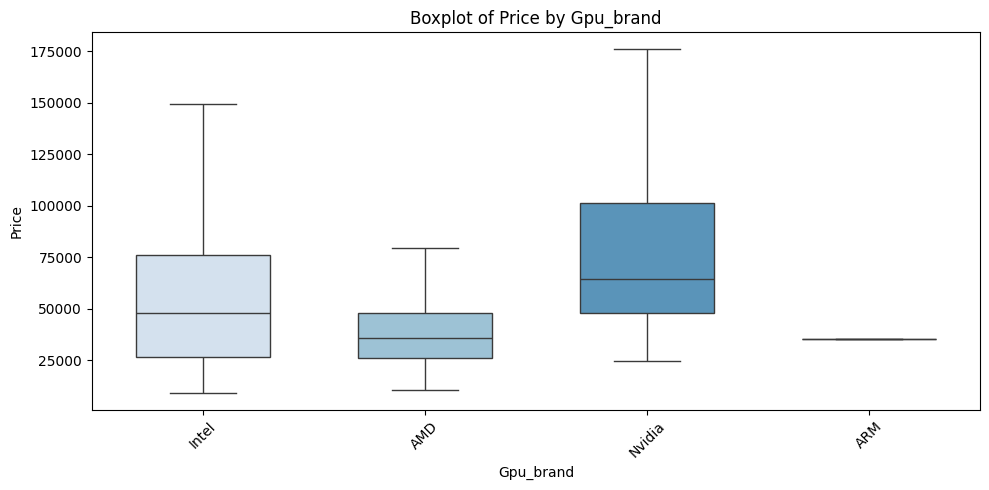

In [328]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    
    sns.boxplot(
        x=df[col],
        y=df['Price'],
        palette='Blues',
        showfliers=False,
        width=0.6
    )

    plt.title(f'Boxplot of Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

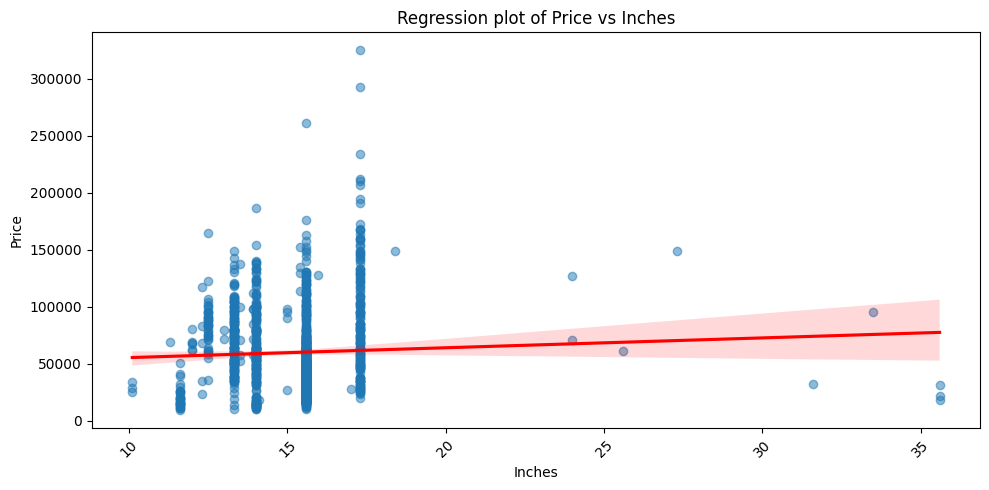

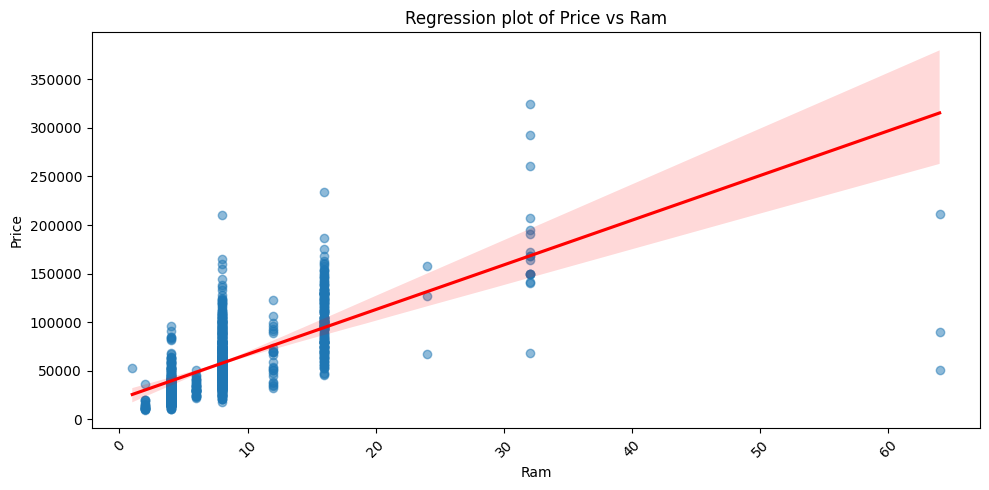

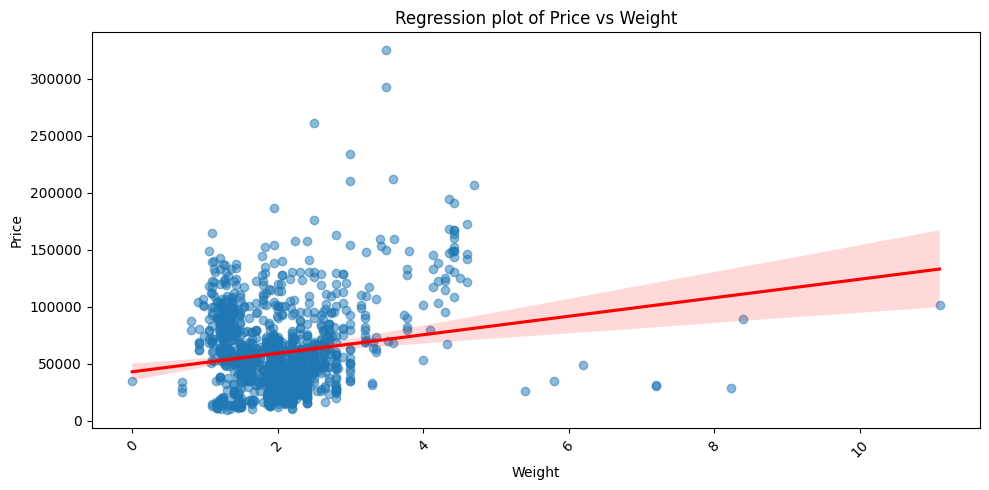

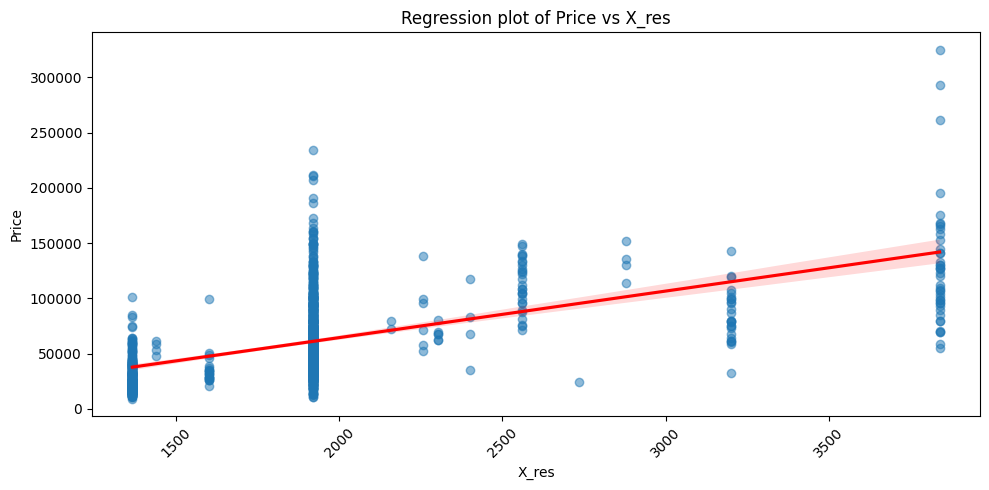

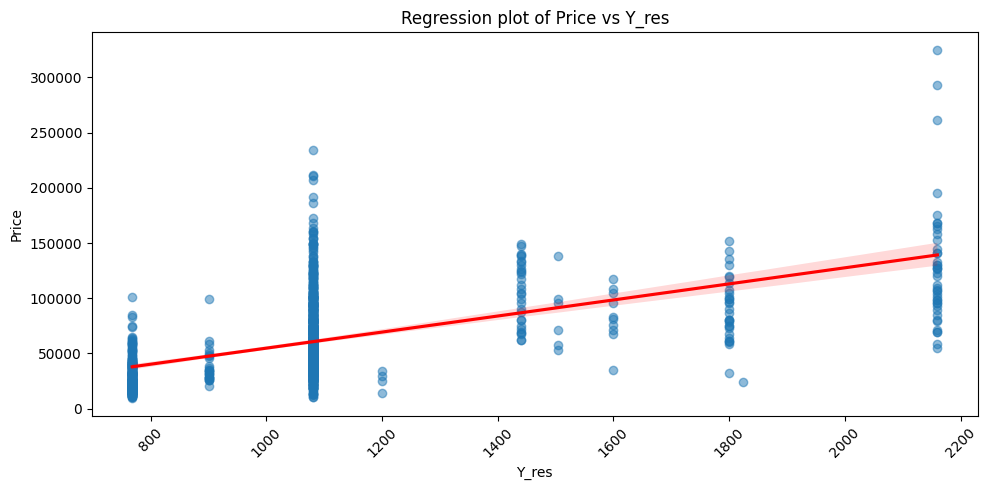

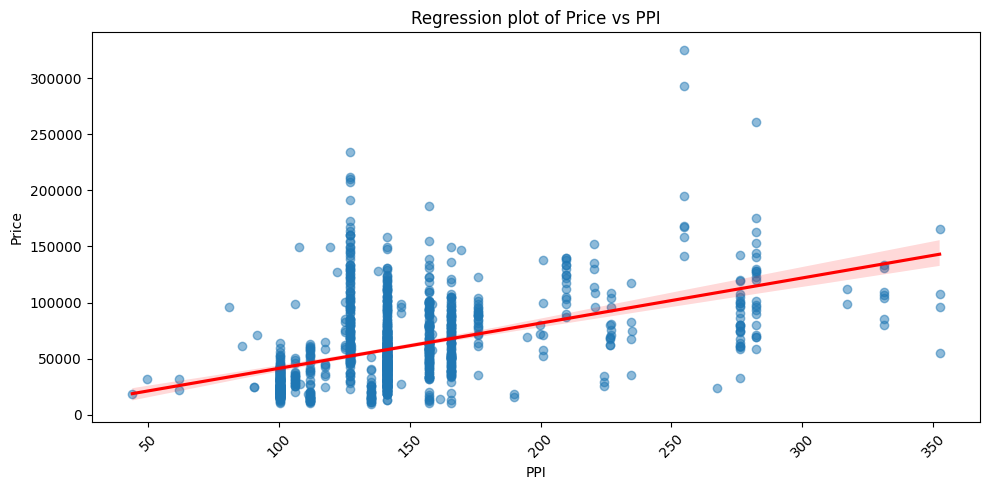

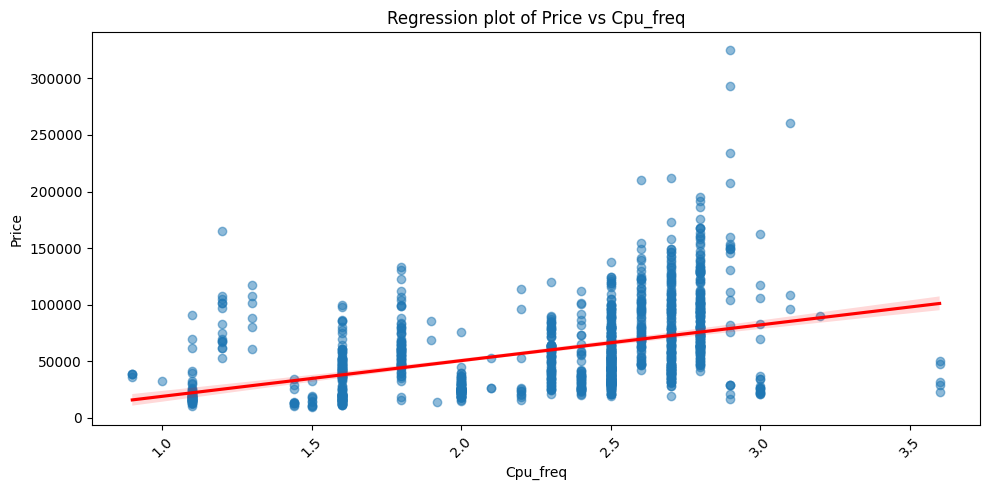

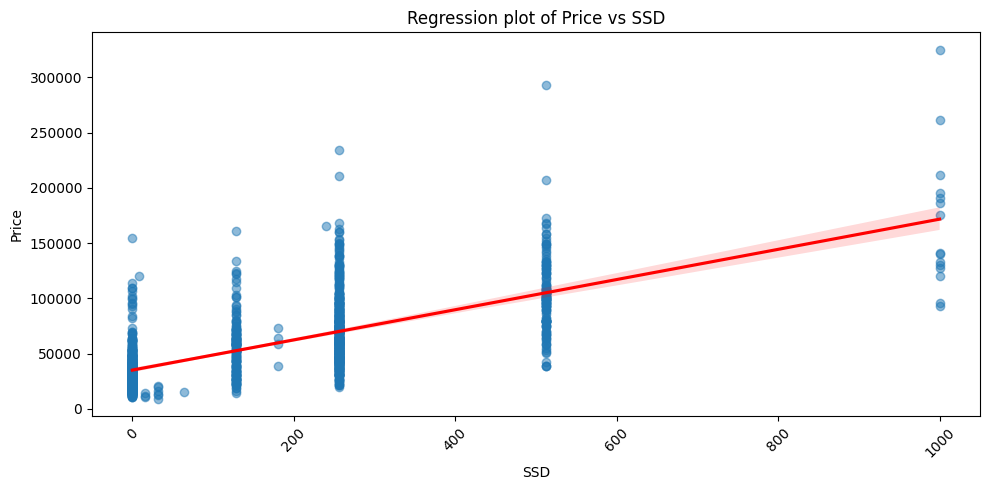

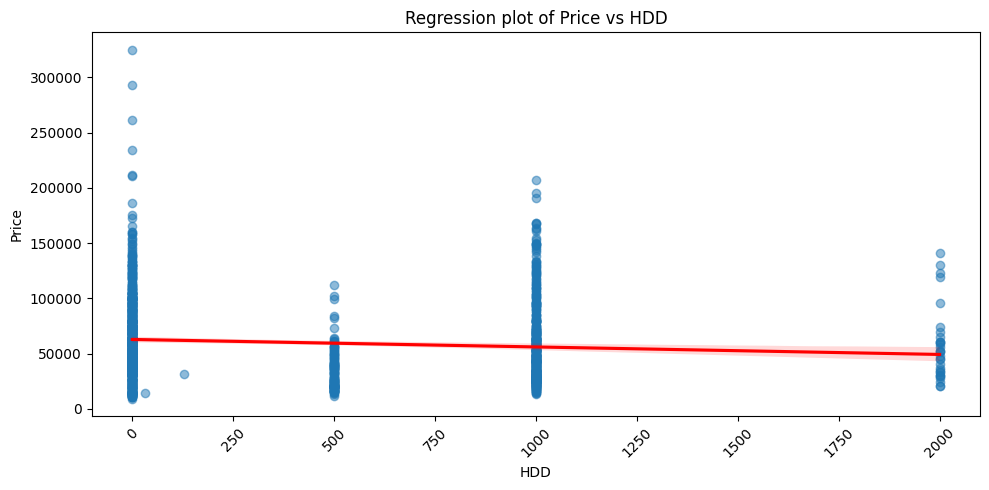

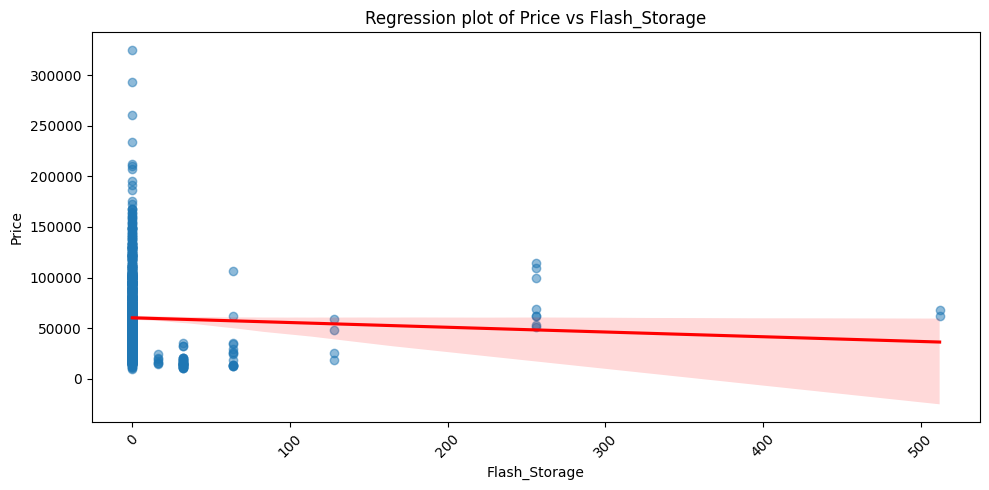

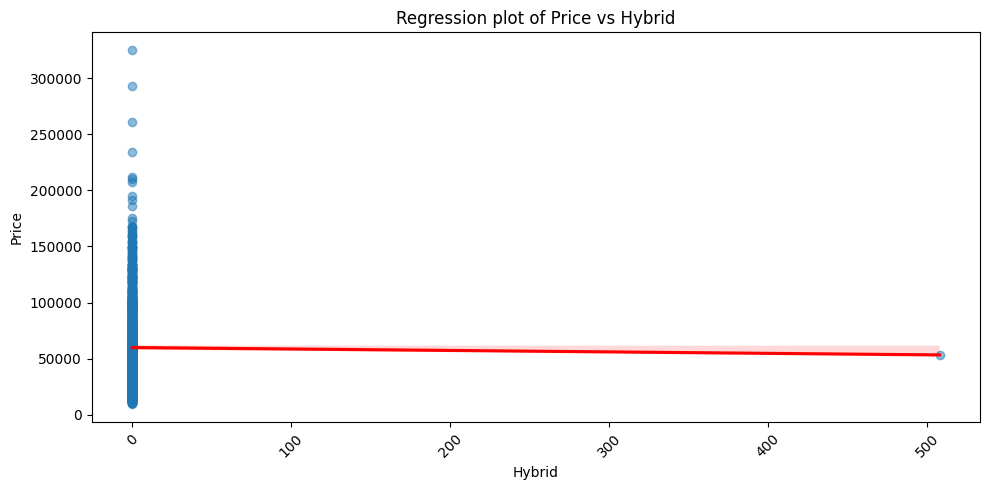

In [342]:
Numerical_cols = df.select_dtypes(include=['int64','float64']).columns
for col in (Numerical_cols):
    if (col != 'Price') & (col != 'Touchscreen') & (col != 'IPS')&(col != 'log_Price'):
     plt.figure(figsize=(10,5))
     sns.regplot(x=df[col], y=df['Price'],scatter_kws={'alpha':0.5},line_kws={'color':'red'})
     plt.title(f'Regression plot of Price vs {col}')
     plt.xticks(rotation=45)
     plt.tight_layout()
     plt.show()
 

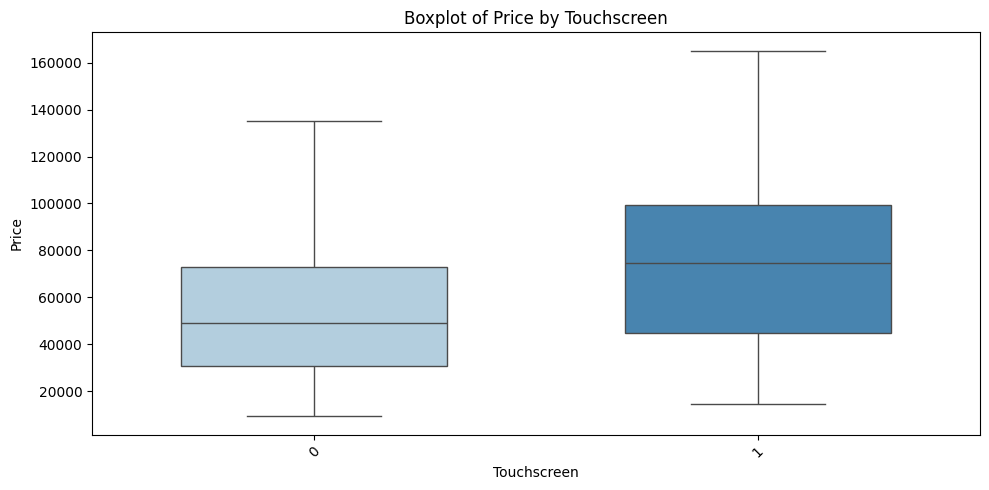

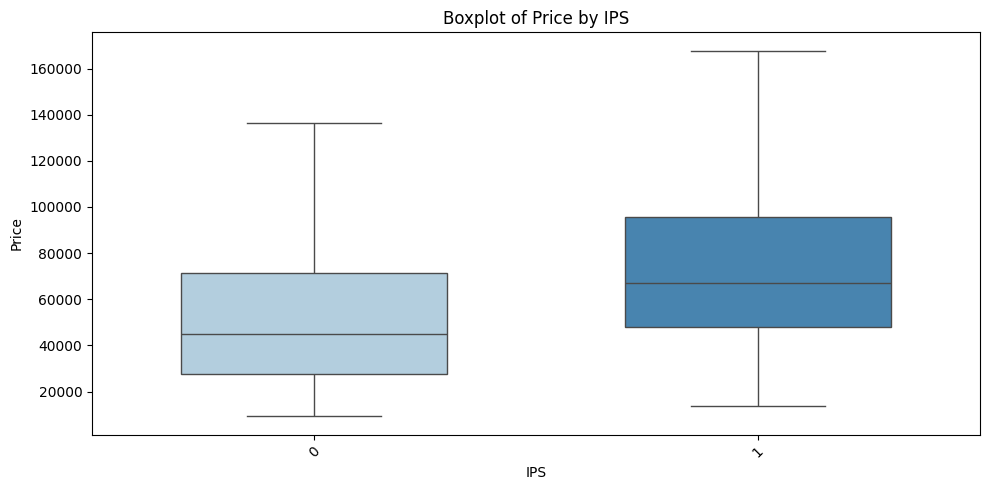

In [222]:
list = ['Touchscreen', 'IPS']
for col in list:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], y=df['Price'], palette='Blues', showfliers=False, width=0.6)
    plt.title(f'Boxplot of Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [330]:
df=pd.get_dummies(df,drop_first=True)
df.head()

,Inches,Ram,Weight,Price,log_Price,Touchscreen,IPS,X_res,Y_res,PPI,...,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,Cpu_brand_Intel,Cpu_brand_Samsung,Gpu_brand_ARM,Gpu_brand_Intel,Gpu_brand_Nvidia
0,13.3,8,1.37,71378.6832,11.175755,0,1,2560.0,1600.0,226.983005,...,False,False,False,False,True,True,False,False,True,False
1,13.3,8,1.34,47895.5232,10.776777,0,0,1440.0,900.0,127.677940,...,False,False,False,False,True,True,False,False,True,False
2,15.6,8,1.86,30636.0000,10.329931,0,0,1920.0,1080.0,141.211998,...,True,False,False,False,False,True,False,False,True,False
3,15.4,16,1.83,135195.3360,11.814476,0,1,2880.0,1800.0,220.534624,...,False,False,False,False,True,True,False,False,False,False
4,13.3,8,1.37,96095.8080,11.473101,0,1,2560.0,1600.0,226.983005,...,False,False,False,False,True,True,False,False,True,False


In [344]:
x=df.drop(columns=['Price','log_Price'])
y=df['log_Price']


In [345]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

num_cols = ['Inches','Ram','Weight','PPI','Cpu_freq',
            'SSD','HDD','Flash_Storage','Hybrid','X_res','Y_res']

x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])


In [352]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [353]:
y_pred = model.predict(x_test_scaled)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



R2: 0.788288814220709
MAE: 0.22669053116877047
RMSE: 0.28383494714146196


In [354]:
train_score = model.score(x_train_scaled, y_train)
test_score = model.score(x_test_scaled, y_test)
print(f"Training R-squared: {train_score:.4f}")
print(f"Testing R-squared: {test_score:.4f}")

Training R-squared: 0.8107
Testing R-squared: 0.7883


In [355]:
train_pred = model.predict(x_train_scaled)

In [356]:

print("===== TRAIN METRICS =====")
print("R²:", r2_score(y_train, train_pred))
print("MAE:", mean_absolute_error(y_train, train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\n===== TEST METRICS =====")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

===== TRAIN METRICS =====
R²: 0.810652286250292
MAE: 0.2146614346973517
RMSE: 0.27157507075549997

===== TEST METRICS =====
R²: 0.788288814220709
MAE: 0.22669053116877047
RMSE: 0.28383494714146196


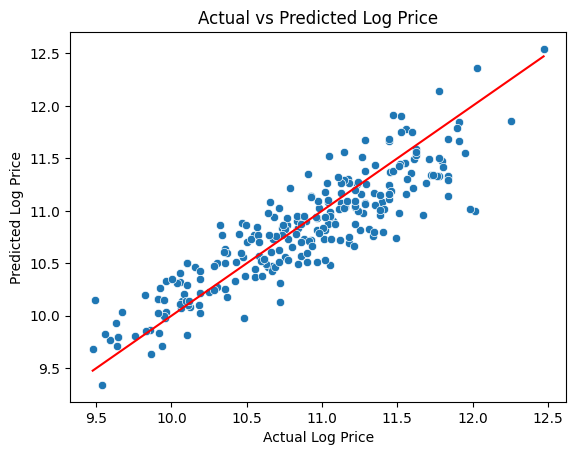

In [357]:
sns.scatterplot(x=y_test, y=y_pred)
sns.lineplot(x=y_test, y=y_test, color='red')  
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Actual vs Predicted Log Price')
plt.show()

Text(0.5, 1.0, 'Residual Plot')

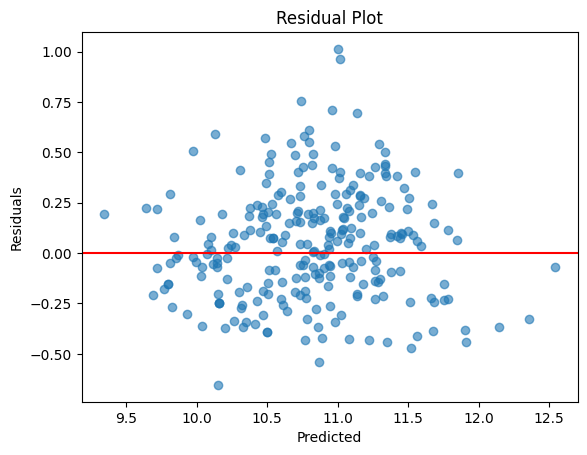

In [358]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals,alpha=.6)
plt.axhline(y=0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

In [361]:
pickle.dump(model, open('laptop_price_model.pkl', 'wb'))

(1273, 51)